In [1]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

# from C_0B_eval import *
from C_0X_defs import *
from C_0Y_evaldefs import *
from scipy.stats import sem, ttest_ind
from misc_recorder import ListRecorder
import pandas as pd

In [2]:
root_ = "/mnt/storage/compling/wavln/"
model_save_ = root_ + "model_save/"

In [3]:
ts = "0912014617" # this timestamp does not contain run number
train_name = "C_0Tf"
res_save_dir = os.path.join(model_save_, f"eval-{train_name}-{ts}")
swapped_res_save_dir = os.path.join(model_save_, f"evalswapped-{train_name}-{ts}")

In [6]:
def get_toplot(hiddens, sepframes1, sepframes2, phi_types, stop_names, offsets=(0, 1), contrast_in="asp", merge=True, hidden_dim=8, lookat="stop", include_map=None, aux_on=None): 
    # collect the start and end frames for each phoneme
    cutstarts = []
    cutends = []
    if lookat == "stop":
        for sepframe1, sepframe2, phi_type in zip(sepframes1, sepframes2, phi_types):
            # if phi_type == 'ST':
            #     cutstarts.append(sepframe1)
            # else:
            #     cutstarts.append(0)
            # we deleted the above code because now we have SIL. 
            cutstarts.append(sepframe1)
            cutends.append(sepframe2)
    elif lookat == "vowel": 
        for sepframe1, sepframe2, phi_type in zip(sepframes1, sepframes2, phi_types):
            # This is to get the vowel part
            cutstarts.append(sepframe2)
            cutends.append(None)
    elif lookat == "pre": 
        for sepframe1, sepframe2, phi_type in zip(sepframes1, sepframes2, phi_types):
            cutstarts.append(0)
            cutends.append(sepframe1)
    else: 
        raise ValueError("Lookat must be one of 'stop' or 'vowel'")
    
    if contrast_in == "asp": 
        tags_list = phi_types
    elif contrast_in == "stop":
        tags_list = stop_names
    elif contrast_in == "vowel":
        tags_list = stop_names  # should pass vowel_names to stop_names
    else:
        raise ValueError("Contrast_in must be one of 'asp' or 'stop'")
    
    if aux_on == "asp": 
        # aux_on is the auxiliary information that we want to for deciding the cut ranges that may not depend on the tag
        aux_on = phi_types
    elif aux_on == "stop": 
        aux_on = stop_names
    elif aux_on == "vowel":
        aux_on = stop_names
    else: 
        # meaning that we are not using any auxiliary information
        aux_on = tags_list
    
    hid_sel = np.empty((0, hidden_dim))
    tag_sel = []
    for (item, start, end, tag, auxtag) in zip(hiddens, cutstarts, cutends, tags_list, aux_on): 
        if include_map is not None and tag not in include_map.keys(): 
            continue

        if isinstance(offsets, tuple):
            offsetstart, offsetend = offsets
        elif isinstance(offsets, dict):
            offsetstart, offsetend = offsets[auxtag]
            # we let the model to report error if the tag is not in the dictionary
        else: 
            raise ValueError("Offsets must be either a tuple or a dictionary")
        
        hid = cutHid(item, start, end, offsetstart, offsetend)
        if merge:
            hid = np.mean(hid, axis=0, keepdims=True)
            hid_sel = np.concatenate((hid_sel, hid), axis=0)
            tag_sel += [include_map[tag] if include_map is not None else tag]
        else: 
            hidlen = hid.shape[0]
            hid_sel = np.concatenate((hid_sel, hid), axis=0)
            tag_sel += [include_map[tag] if include_map is not None else tag] * hidlen
    return hid_sel, np.array(tag_sel)


In [ ]:
results = []
for test_type in ['normal', 'swapped']:
    for model_type in ['recon4-phi', 'recon8-phi', 'recon16-phi', 'recon32-phi', 'recon64-phi', 'recon96-phi']: 
        for model_condition in ['b']: 
            for run in range(1, 6): 
                if test_type == 'normal': 
                    res_read_dir = os.path.join(res_save_dir, f"{model_type}", f"{model_condition}", f"{run}")
                elif test_type == 'swapped': 
                    res_read_dir = os.path.join(swapped_res_save_dir, f"{model_type}", f"{model_condition}", f"{run}")
                
                for epoch in range(0, 101): 
                    hidrep_handler = DictResHandler(whole_res_dir=res_read_dir, 
                                        file_prefix=f"all-{epoch}")
                    hidrep_handler.read()
                    hidrep = hidrep_handler.res
                    dimension = 0
                    if model_type == 'recon4-phi':
                        dimension = 4
                    elif model_type == 'recon8-phi': 
                        dimension = 8
                    elif model_type == 'recon16-phi': 
                        dimension = 16
                    elif model_type == 'recon32-phi': 
                        dimension = 32
                    elif model_type == 'recon64-phi':
                        dimension = 64
                    elif model_type == 'recon96-phi':
                        dimension = 96

                    ori = hidrep['ori']
                    recon = hidrep['recon']

                    # all_sepframes1 = hidrep["sep-frame1"]
                    # all_sepframes2 = hidrep["sep-frame2"]

                    # hidr_ori, tags_ori = get_toplot(hiddens=all_ori, 
                    #                                 sepframes1=all_sepframes1,
                    #                                 sepframes2=all_sepframes2,
                    #                                 phi_types=all_phi_type,
                    #                                 stop_names=all_stop_names,
                    #                                 offsets=(0, 1), 
                    #                                 contrast_in=test_name_label, 
                    #                                 merge=merge_one_vector, 
                    #                                 hidden_dim=64, 
                    #                                 lookat=test_name_lookat)

                    stacked_ori = np.vstack(ori)
                    stacked_recon = np.vstack(recon)

                    data = np.mean(np.square(stacked_ori - stacked_recon))

                    datadict = {'dimension': dimension, 'model_condition': model_condition, 'run': run, "epoch": epoch, "test_type": test_type, 'recon_loss': data}
                    results.append(datadict)

In [20]:
resultsdf = pd.DataFrame(results)

In [21]:
resultsdf.to_csv(f"{model_save_}/recon_loss_{ts}.csv", index=False)

In [22]:
resultsdf = pd.read_csv(f"{model_save_}/recon_loss_{ts}.csv")

In [23]:
def cosine_similarity_axis(A: np.ndarray, B: np.ndarray, axis: int = 0) -> np.ndarray:
    # Calculate the dot product along the specified axis
    dot_product = np.sum(A * B, axis=axis)
    # Calculate the norm (magnitude) of each vector along the specified axis
    norm_A = np.linalg.norm(A, axis=axis)
    norm_B = np.linalg.norm(B, axis=axis)
    # Calculate the cosine similarity
    cosine_sim = dot_product / (norm_A * norm_B)
    return cosine_sim

In [31]:
cosine_similarity_axis(stacked_ori, stacked_recon, axis=1).shape

(19376,)

In [24]:
def df_to_np_array(df, run_col, epoch_col, score_col):
    # Pivot the DataFrame to get a table with runs as rows and epochs as columns
    pivot_df = df.pivot(index=run_col, columns=epoch_col, values=score_col)
    # Convert the pivoted DataFrame to a NumPy array
    result_array = pivot_df.values
    return result_array

In [26]:
from C_0Tf_n_integrate_abx_pph import plot_many
mk(f"{model_save_}/recon_loss_{ts}/")
for dimension in [4, 8, 16, 32, 64, 96]:
    col = []
    for test_type in ['normal', 'swapped']: 
        to_add_data = resultsdf[(resultsdf['dimension'] == dimension) & (resultsdf['test_type'] == test_type)]
        to_add_data_good = df_to_np_array(to_add_data, 'run', 'epoch', 'recon_loss')
        col.append(to_add_data_good)
    plot_many(col, ['normal', 'swapped'], f"{model_save_}/recon_loss_{ts}/{dimension}_recon_loss.png")

In [18]:
resultsdf

,dimension,model_condition,run,epoch,test_type,recon_loss
0,4,b,1,0,normal,1.172213
1,4,b,1,1,normal,0.981734
2,4,b,1,2,normal,0.784990
3,4,b,1,3,normal,0.688995
4,4,b,1,4,normal,0.643922
...,...,...,...,...,...,...
6055,0,b,5,96,swapped,0.021762
6056,0,b,5,97,swapped,0.021320
6057,0,b,5,98,swapped,0.021936
6058,0,b,5,99,swapped,0.021412


In [ ]:
resultsdf = pd.DataFrame(results)

In [ ]:
resultsdf

,dimension,model_condition,run,recon_loss
0,4,u,1,0.360552
1,4,u,2,0.364517
2,4,u,3,0.363051
3,4,u,4,0.399515
4,4,u,5,0.361524
5,4,b,1,0.393435
6,4,b,2,0.329338
7,4,b,3,0.385332
8,4,b,4,0.464260
9,4,b,5,0.435483


In [ ]:
# Perform the groupby and calculate the mean for the remaining column
grouped_df = resultsdf.groupby(["dimension", "model_condition"])["recon_loss"].mean().reset_index()

In [ ]:
grouped_df

,dimension,model_condition,recon_loss
0,4,b,0.401569
1,4,u,0.369832
2,8,b,0.222804
3,8,u,0.216290
4,16,b,0.125158
5,16,u,0.119112
6,32,b,0.078389
7,32,u,0.075468


In [ ]:
gbres = grouped_df[grouped_df['model_condition'] == 'b']
gures = grouped_df[grouped_df['model_condition'] == 'u']

In [ ]:
outstr = ""
for dim in [4, 8, 16, 32]: 
    r = gbres[gbres['dimension'] == dim]['recon_loss'].values[0]
    outstr += "\overline{\epsilon}_{%d} = %.4f, " % (dim, r)

In [ ]:
print(outstr)

\overline{\epsilon}_{4} = 0.4016, \overline{\epsilon}_{8} = 0.2228, \overline{\epsilon}_{16} = 0.1252, \overline{\epsilon}_{32} = 0.0784, 


In [ ]:
outstr = ""
for dim in [4, 8, 16, 32]: 
    r = gures[gures['dimension'] == dim]['recon_loss'].values[0]
    outstr += "\overline{\epsilon}_{%d} = %.4f, " % (dim, r)

In [ ]:
print(outstr)

\overline{\epsilon}_{4} = 0.3698, \overline{\epsilon}_{8} = 0.2163, \overline{\epsilon}_{16} = 0.1191, \overline{\epsilon}_{32} = 0.0755, 


In [ ]:
bres = resultsdf[resultsdf['model_condition'] == 'b']
ures = resultsdf[resultsdf['model_condition'] == 'u']

In [ ]:
bres["recon_loss"].corr(bres["dimension"]), ures["recon_loss"].corr(ures["dimension"])

(-0.8299008887209766, -0.8565714128555049)

# Well Formedness Quantitative Check

In [31]:
from C_0Tf_n_integrate_abx_pph import plot_many
import numpy as np 

In [20]:
root_ = "/mnt/storage/compling/wavln/"
model_save_ = root_ + "model_save/"
ts = "0912014617" # this timestamp does not contain run number
train_name = "C_0Tf"
res_save_dir = os.path.join(model_save_, f"eval-{train_name}-{ts}")
swapped_res_save_dir = os.path.join(model_save_, f"evalswapped-{train_name}-{ts}")

In [37]:
result_dir = os.path.join(res_save_dir, "reconloss-stop-stop")
model_type = "recon4-phi"
model_condition = "b"
strseq_learned_runs = "12345"
zlevel = "reconori"
test_type = "normal"

subset_size = 50  # Number of elements in each random subset 
num_samples = 500  # Number of random samples 

In [34]:
def random_subset_mean_difference(set1, set2, subset_size, num_samples): 
    differences = []
    for _ in range(num_samples): 
        subset1_idx = np.random.choice(set1.shape[0], size=subset_size, replace=False)
        subset2_idx = np.random.choice(set2.shape[0], size=subset_size, replace=False)
        subset1 = set1[subset1_idx]
        subset2 = set2[subset2_idx]
        mean_diff = np.mean(subset1, axis=0) - np.mean(subset2, axis=0)
        differences.append(mean_diff) 
    return np.array(differences) 

In [44]:
mean_diffs = []
for dimension in [4, 8, 16, 32, 48, 64, 96]: 
    model_type = f"recon{dimension}-phi"
    cossimres_normal = np.load(os.path.join(result_dir, f"07-save-ari-{model_type}-{model_condition}-{strseq_learned_runs}-{zlevel}-normal.npy"))
    cossimres_swapped = np.load(os.path.join(result_dir, f"07-save-ari-{model_type}-{model_condition}-{strseq_learned_runs}-{zlevel}-swapped.npy"))

    # mean_normal = cossimres_normal.mean(axis=0)
    # mean_swapped = cossimres_swapped.mean(axis=0)
    # mean_diff = mean_normal - mean_swapped
    differences = random_subset_mean_difference(cossimres_normal, cossimres_swapped, subset_size, num_samples)
    # cossimres_diff = cossimres_normal - cossimres_swapped
    # plot_many(mean_diff, ['diff'], f"{model_save_}/recon_loss_diff_{ts}/{dimension}_recon_loss.png")
    mean_diffs.append(differences)

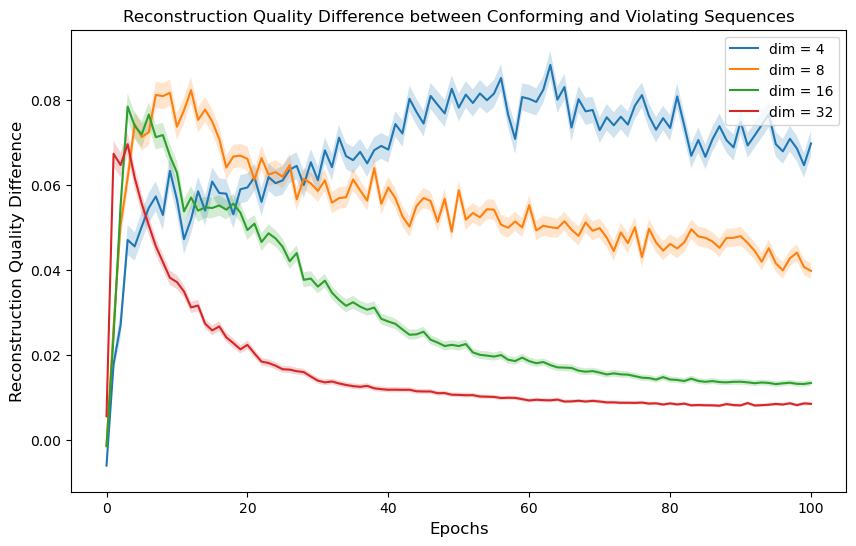

In [87]:
import matplotlib.pyplot as plt

# Calculate the mean and standard error of the mean (SEM) for each dimension
mean_diffs_mean = [np.mean(diff, axis=0) for diff in mean_diffs]
mean_diffs_sem = [sem(diff, axis=0) for diff in mean_diffs]

# Plot the mean differences with confidence intervals for each dimension
plt.figure(figsize=(10, 6))
for mean_diff, sem_diff, dimension in zip(mean_diffs_mean, mean_diffs_sem, [4, 8, 16, 32]):
    plt.plot(mean_diff, label=f'dim = {dimension}')
    plt.fill_between(range(len(mean_diff)), mean_diff - sem_diff, mean_diff + sem_diff, alpha=0.2)

plt.xlabel('Epochs', fontdict={"fontsize":12})
plt.ylabel('Reconstruction Quality Difference', fontdict={"fontsize":12})
plt.title('Reconstruction Quality Difference between Conforming and Violating Sequences', fontdict={"fontsize":12})
plt.legend()
plt.show()

In [56]:
attn_dir = res_save_dir

In [59]:
stattns = []
tattns = []
for dimension in [4, 8, 16, 32, 48, 64, 96]: 
    model_type = f"recon{dimension}-phi"
    with open(os.path.join(attn_dir, f"attnepochtraj-at-all-{model_type}-b-12345.attnres"), 'rb') as f:
        attnres = pickle.load(f)
    stres = attnres["ST"]["t2s"].T
    tres = attnres["T"]["t2s"].T
    stattns.append(stres)
    tattns.append(tres)

# Quantify the Comparison

In [61]:
from sklearn.preprocessing import StandardScaler

In [62]:
allcorrres = {}

### Pearson's Correlation

In [63]:
from scipy.stats import pearsonr

In [64]:
allcorrres["pearsonr"] = []
for i, hiddim in enumerate([4, 8, 16, 32, 48, 64, 96]): 
    attnres = stattns[i]
    diffres = mean_diffs[i]

    meaned_attnres = np.mean(attnres, axis=0)
    meaned_diffres = np.mean(diffres, axis=0)

    scaler = StandardScaler()
    meaned_attnres_norm = scaler.fit_transform(meaned_attnres.reshape(-1, 1)).flatten()
    meaned_diffres_norm = scaler.fit_transform(meaned_diffres.reshape(-1, 1)).flatten()

    allcorrres["pearsonr"].append(pearsonr(meaned_attnres_norm, meaned_diffres_norm)[0])


In [65]:
allcorrres["pearsonr"]

[0.9387615927982246,
 0.892712278183439,
 0.9501988110832468,
 0.950759922009884,
 0.9423473456807958,
 0.9500949945694626,
 0.9219072717827808]

### Spearman's Correlation

In [66]:
from scipy.stats import spearmanr

In [67]:
allcorrres["spearman"] = []
for i, hiddim in enumerate([4, 8, 16, 32, 48, 64, 96]): 
    attnres = stattns[i]
    diffres = mean_diffs[i]

    meaned_attnres = np.mean(attnres, axis=0)
    meaned_diffres = np.mean(diffres, axis=0)

    scaler = StandardScaler()
    meaned_attnres_norm = scaler.fit_transform(meaned_attnres.reshape(-1, 1)).flatten()
    meaned_diffres_norm = scaler.fit_transform(meaned_diffres.reshape(-1, 1)).flatten()

    allcorrres["spearman"].append(pearsonr(meaned_attnres_norm, meaned_diffres_norm)[0])


In [68]:
allcorrres["spearman"]

[0.9387615927982246,
 0.892712278183439,
 0.9501988110832468,
 0.950759922009884,
 0.9423473456807958,
 0.9500949945694626,
 0.9219072717827808]

### DTW

In [69]:
from dtaidistance import dtw
from dtaidistance import dtw_visualisation as dtwvis
import matplotlib.pyplot as plt

In [70]:
allcorrres["dtw"] = []
for i, hiddim in enumerate([4, 8, 16, 32, 48, 64, 96]): 
    attnres = stattns[i]
    diffres = mean_diffs[i]

    meaned_attnres = np.mean(attnres, axis=0)
    meaned_diffres = np.mean(diffres, axis=0)

    scaler = StandardScaler()
    meaned_attnres_norm = scaler.fit_transform(meaned_attnres.reshape(-1, 1)).flatten()
    meaned_diffres_norm = scaler.fit_transform(meaned_diffres.reshape(-1, 1)).flatten()

    allcorrres["dtw"].append(dtw.distance(meaned_attnres_norm, meaned_diffres_norm))

In [71]:
allcorrres["dtw"]

[2.5284534434231625,
 2.9339475198807436,
 2.1838363112206625,
 2.4715960718541425,
 3.0511068886675083,
 2.9727424489686016,
 3.677607389569962]

### Euclidean Distance

In [72]:
from scipy.spatial.distance import euclidean

In [73]:
allcorrres["euclidean"] = []
for i, hiddim in enumerate([4, 8, 16, 32, 48, 64, 96]): 
    attnres = stattns[i]
    diffres = mean_diffs[i]

    meaned_attnres = np.mean(attnres, axis=0)
    meaned_diffres = np.mean(diffres, axis=0)

    scaler = StandardScaler()
    meaned_attnres_norm = scaler.fit_transform(meaned_attnres.reshape(-1, 1)).flatten()
    meaned_diffres_norm = scaler.fit_transform(meaned_diffres.reshape(-1, 1)).flatten()

    allcorrres["euclidean"].append(euclidean(meaned_attnres_norm, meaned_diffres_norm))

In [74]:
allcorrres["euclidean"]

[3.517123584657188,
 4.655332355662248,
 3.171725114423411,
 3.153806583274464,
 3.4125996072803555,
 3.1750293269854146,
 3.971741554563938]

In [75]:
allcorrres

{'pearsonr': [0.9387615927982246,
  0.892712278183439,
  0.9501988110832468,
  0.950759922009884,
  0.9423473456807958,
  0.9500949945694626,
  0.9219072717827808],
 'spearman': [0.9387615927982246,
  0.892712278183439,
  0.9501988110832468,
  0.950759922009884,
  0.9423473456807958,
  0.9500949945694626,
  0.9219072717827808],
 'dtw': [2.5284534434231625,
  2.9339475198807436,
  2.1838363112206625,
  2.4715960718541425,
  3.0511068886675083,
  2.9727424489686016,
  3.677607389569962],
 'euclidean': [3.517123584657188,
  4.655332355662248,
  3.171725114423411,
  3.153806583274464,
  3.4125996072803555,
  3.1750293269854146,
  3.971741554563938]}